# 02 - Feature Engineering

Companion to `src/train/features.py`. Walks through the engineered feature set, shows what each group contains, and identifies which features carry the most fraud signal.

**Prerequisite:** processed data must exist:
```bash
python -m src.train.features
```

In [1]:
# Install required packages if not already present (safe to re-run)
import subprocess, sys
pkgs = ["pyarrow", "pandas", "numpy", "matplotlib", "seaborn"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + pkgs)

0

In [2]:
import sys
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
PROCESSED = ROOT / 'data' / 'processed'

# Make src.train.features importable from the notebook
sys.path.insert(0, str(ROOT))
from src.train.features import FeaturePipeline, PipelineState

# pipeline.pkl was pickled with __main__ as the module when features.py ran
# as a script; inject the classes so pickle can resolve them on load.
import __main__
__main__.FeaturePipeline = FeaturePipeline
__main__.PipelineState = PipelineState

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette('Set2')
print('Ready')

Ready


## 1. Load processed data

In [3]:
df = pd.read_parquet(PROCESSED / 'train.parquet')
print(f'Shape       : {df.shape}')
print(f'Fraud rate  : {df["isFraud"].mean():.2%}')
df.head(3)

Shape       : (590540, 260)
Fraud rate  : 3.50%


,isFraud,TransactionAmt,hour,day_of_week,day_of_month,month,email_match,r_email_anon,p_email_anon,card1_amt_mean,...,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11
0,0,68.5,0,4,1,12,0,0,0,351.931163,...,125800.5,0.0,0.0,0.0,0.0,14.0,-34.0,0.0,0.0,100.0
1,0,29.0,0,4,1,12,0,0,0,234.292753,...,125800.5,0.0,0.0,0.0,0.0,14.0,-34.0,0.0,0.0,100.0
2,0,59.0,0,4,1,12,0,0,0,97.015542,...,125800.5,0.0,0.0,0.0,0.0,14.0,-34.0,0.0,0.0,100.0


In [4]:
y = df['isFraud']
X = df.drop(columns=['isFraud'])

fraud = X[y == 1]
legit = X[y == 0]

print(f'Feature count : {X.shape[1]}')
print(f'Fraud samples : {len(fraud):,}')
print(f'Legit samples : {len(legit):,}')
print(f'Dtype counts  :')
print(X.dtypes.value_counts().to_string())

Feature count : 259
Fraud samples : 20,663
Legit samples : 569,877
Dtype counts  :
float64    238
int16       13
int8         7
int64        1


## 2. Feature groups

In [5]:
cols = X.columns.tolist()

groups = {
    'Transaction base' : [c for c in cols if c == 'TransactionAmt'],
    'Temporal'         : [c for c in cols if c in ('hour', 'day_of_week', 'day_of_month', 'month')],
    'Email'            : [c for c in cols if 'email' in c.lower() or 'Email' in c],
    'Card aggregates'  : [c for c in cols if c.startswith('card1_') or c.startswith('uid_') or 'zscore' in c],
    'Distance'         : [c for c in cols if c.startswith('dist')],
    'Target-encoded'   : [c for c in cols if c.endswith('_te')],
    'Label-encoded'    : [c for c in cols if c in ('ProductCD', 'card4', 'card6', 'DeviceType')
                          or (c.startswith('M') and len(c) == 2)],
    'V-features'       : [c for c in cols if c.startswith('V')],
    'C-features'       : [c for c in cols if c.startswith('C') and c[1:].isdigit()],
    'D-features'       : [c for c in cols if c.startswith('D') and c[1:].isdigit()],
    'ID features'      : [c for c in cols if c.startswith('id_')],
}

summary = pd.DataFrame([
    {'Group': g, 'Count': len(v), 'Example columns': ', '.join(v[:4])}
    for g, v in groups.items()
])
print(summary.to_string(index=False))
print(f'\nTotal accounted for: {sum(len(v) for v in groups.values())} / {X.shape[1]}')

           Group  Count                                              Example columns
Transaction base      1                                               TransactionAmt
        Temporal      4                       hour, day_of_week, day_of_month, month
           Email      5    email_match, r_email_anon, p_email_anon, P_emaildomain_te
 Card aggregates      9 card1_amt_mean, card1_amt_std, card1_txn_count, uid_amt_mean
        Distance      2                                                 dist1, dist2
  Target-encoded      8                       card1_te, card2_te, card3_te, card5_te
   Label-encoded     13                                  ProductCD, card4, card6, M1
      V-features    180                                               V1, V2, V3, V4
      C-features     14                                               C1, C2, C3, C4
      D-features     15                                               D1, D2, D3, D4
     ID features     11                                   id_01, 

## 3. Null values and data quality

In [6]:
null_pct = X.isnull().mean()
n_null_cols = (null_pct > 0).sum()

if n_null_cols == 0:
    print(f'No nulls in any of the {X.shape[1]} features - pipeline imputation is complete.')
else:
    high_null = null_pct[null_pct > 0.05].sort_values(ascending=False)
    print(f'{n_null_cols} columns with nulls; {len(high_null)} above 5%')
    fig, ax = plt.subplots(figsize=(8, max(3, len(high_null) * 0.35)))
    high_null.plot.barh(ax=ax)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title('Features with >5% missing values')
    plt.tight_layout()
    plt.show()

No nulls in any of the 259 features - pipeline imputation is complete.


## 4. Transaction amount

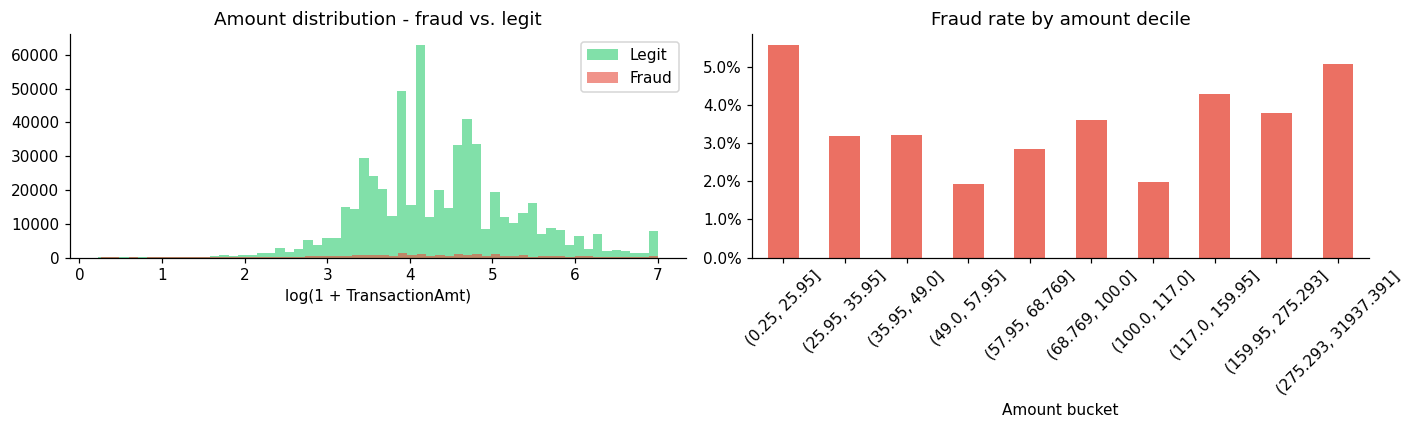

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cap = X['TransactionAmt'].quantile(0.99)
for label, subset, color, name in [(0, legit, '#2ecc71', 'Legit'), (1, fraud, '#e74c3c', 'Fraud')]:
    axes[0].hist(
        np.log1p(subset['TransactionAmt'].clip(upper=cap)),
        bins=60, alpha=0.6, color=color, label=name
    )
axes[0].set_xlabel('log(1 + TransactionAmt)')
axes[0].set_title('Amount distribution - fraud vs. legit')
axes[0].legend()

tmp = pd.DataFrame({'amt': X['TransactionAmt'], 'isFraud': y})
tmp['bucket'] = pd.qcut(tmp['amt'], q=10, duplicates='drop')
tmp.groupby('bucket', observed=True)['isFraud'].mean().plot.bar(
    ax=axes[1], color='#e74c3c', alpha=0.8
)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title('Fraud rate by amount decile')
axes[1].set_xlabel('Amount bucket')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. Temporal features

Temporal columns found: ['hour', 'day_of_week', 'day_of_month', 'month']


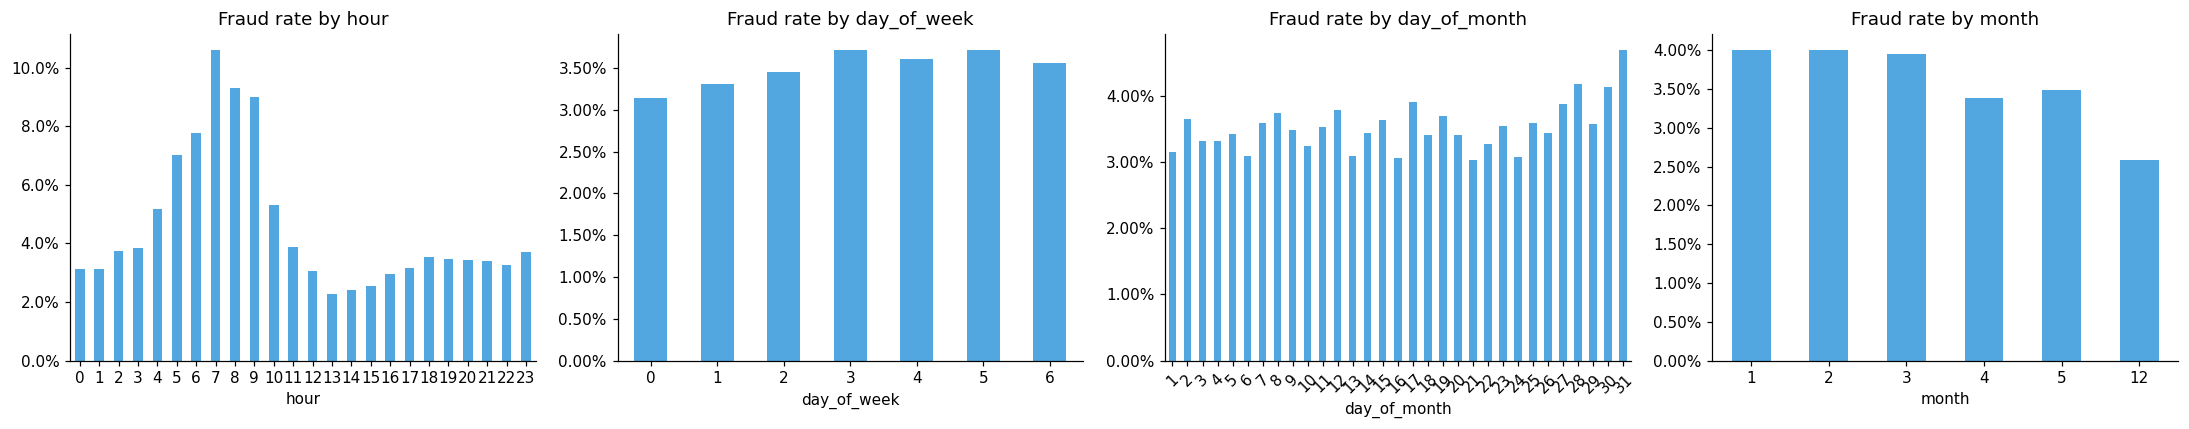

In [8]:
temporal_cols = [c for c in ('hour', 'day_of_week', 'day_of_month', 'month') if c in X.columns]
print('Temporal columns found:', temporal_cols)

fig, axes = plt.subplots(1, len(temporal_cols), figsize=(5 * len(temporal_cols), 4))
if len(temporal_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, temporal_cols):
    tmp = pd.DataFrame({col: X[col], 'isFraud': y})
    tmp.groupby(col)['isFraud'].mean().plot.bar(ax=ax, color='#3498db', alpha=0.85)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title(f'Fraud rate by {col}')
    ax.tick_params(axis='x', rotation=0 if col != 'day_of_month' else 45)

plt.tight_layout()
plt.show()

## 6. Email features

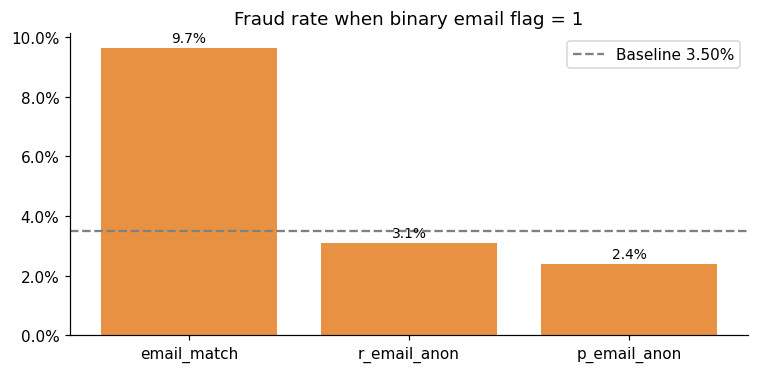

In [9]:
email_binary = [c for c in ('email_match', 'r_email_anon', 'p_email_anon') if c in X.columns]

if email_binary:
    rates = {col: y[X[col] == 1].mean() for col in email_binary}
    baseline = y.mean()

    fig, ax = plt.subplots(figsize=(7, 3.5))
    bars = ax.bar(rates.keys(), rates.values(), color='#e67e22', alpha=0.85)
    ax.axhline(baseline, color='gray', linestyle='--', label=f'Baseline {baseline:.2%}')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title('Fraud rate when binary email flag = 1')
    ax.legend()
    for bar, (k, v) in zip(bars, rates.items()):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.002, f'{v:.1%}', ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('Binary email columns not found in dataset.')

## 7. Top features by correlation with fraud

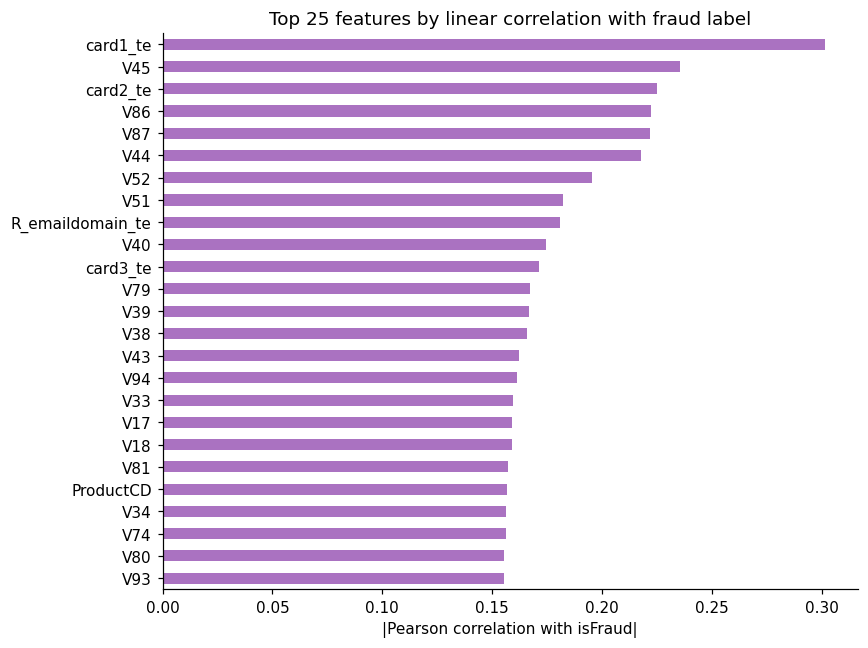


Top 10:
card1_te            0.301325
V45                 0.235436
card2_te            0.225128
V86                 0.222343
V87                 0.221568
V44                 0.217870
V52                 0.195492
V51                 0.182007
R_emaildomain_te    0.180750
V40                 0.174672


In [10]:
numeric_X = X.select_dtypes(include=[np.number])
corr = numeric_X.corrwith(y.astype(float)).abs().dropna().sort_values(ascending=False)
top_corr = corr.head(25)

fig, ax = plt.subplots(figsize=(8, 6))
top_corr.plot.barh(ax=ax, color='#9b59b6', alpha=0.85)
ax.set_xlabel('|Pearson correlation with isFraud|')
ax.set_title('Top 25 features by linear correlation with fraud label')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\nTop 10:')
print(top_corr.head(10).to_string())

## 8. Pipeline inspection

In [11]:
pipeline_path = PROCESSED / 'pipeline.pkl'

with open(pipeline_path, 'rb') as f:
    pipeline = pickle.load(f)

s = pipeline.state
print(f'Pipeline type          : {type(pipeline).__name__}')
print(f'Feature columns        : {len(s.feature_cols)}')
print(f'Target-encode mappings : {list(s.target_encode_maps.keys())}')
print(f'Label-encode mappings  : {list(s.label_encode_maps.keys())}')
print(f'Global amount mean     : {s.global_amt_mean:.2f}')
print(f'Global amount std      : {s.global_amt_std:.2f}')
print(f'\nFirst 10 feature cols  :')
print(s.feature_cols[:10])

Pipeline type          : FeaturePipeline
Feature columns        : 259
Target-encode mappings : ['card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain']
Label-encode mappings  : ['ProductCD', 'card4', 'card6', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'DeviceType', 'p_email_root', 'r_email_root']
Global amount mean     : 135.03
Global amount std      : 239.16

First 10 feature cols  :
['TransactionAmt', 'hour', 'day_of_week', 'day_of_month', 'month', 'email_match', 'r_email_anon', 'p_email_anon', 'card1_amt_mean', 'card1_amt_std']


## 9. Correlation heatmap - top 12 features

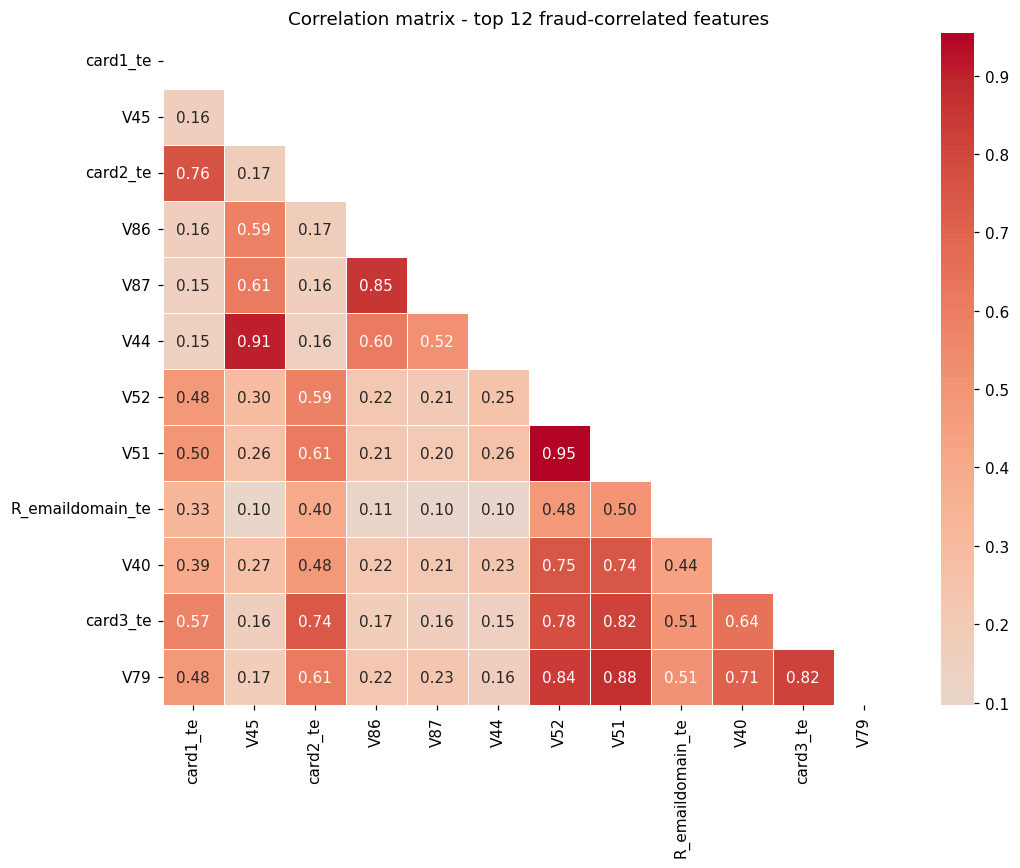

In [12]:
top_feats = top_corr.head(12).index.tolist()
corr_matrix = numeric_X[top_feats].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5, ax=ax
)
ax.set_title('Correlation matrix - top 12 fraud-correlated features')
plt.tight_layout()
plt.show()

## 10. Near-zero variance check

In [13]:
var = numeric_X.var().sort_values()
low_var = var[var < 1e-6]

if low_var.empty:
    print(f'All {numeric_X.shape[1]} numeric features have variance > 1e-6.')
else:
    print(f'{len(low_var)} near-constant columns (candidates for dropping):')
    print(low_var.to_string())

1 near-constant columns (candidates for dropping):
M4    0.0


## Summary

| | |
|---|---|
| Total rows | 590,540 |
| Engineered features | 259 |
| Fraud rate | ~3.5% (severe class imbalance → AUC-PR is primary metric) |
| Strongest signal | target-encoded card/email features, select V-features |
| Nulls after pipeline | 0 |
| Object columns | 0 (all label-encoded to int) |

Next step: `src/train/train.py` runs 24 MLflow experiments (12 XGBoost × 12 LightGBM) on this feature matrix and registers the best AUC-PR model.